In [41]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [57]:
path = "data/img.png"
img = Image.open(path).convert('RGB')
img = np.array(img)

X = img.reshape(-1, 3).astype(np.float32) #rgb
img.shape, X.shape

((395, 591, 3), (233445, 3))

In [58]:
K = 3 #k clusters
max_iters = 100

ran_idx = np.random.choice(X.shape[0], K, replace=False)
centroids = X[ran_idx]

In [59]:
for i in range(max_iters):
    dist = np.zeros((X.shape[0], K))

    for j in range(K):
        diff = X - centroids[j]

        dist[:, j] = np.sqrt(np.sum(diff**2, axis=1))
    
    y = np.argmin(dist, axis=1)
    new_centroid = np.zeros_like(centroids)

    for j in range(K):
        cluster_p = X[y == j]

        if len(cluster_p) > 0:
            new_centroid[j] = np.mean(cluster_p, axis=0)
        else:
            new_centroid[j] = centroids[j]

    if np.allclose(centroids, new_centroid):
        print(f"Converged in {i} iterations")
        break

    centroids = new_centroid

Converged in 25 iterations


In [60]:
pixels = centroids[y]
result = pixels.reshape(img.shape)
result = result.astype(np.uint8)

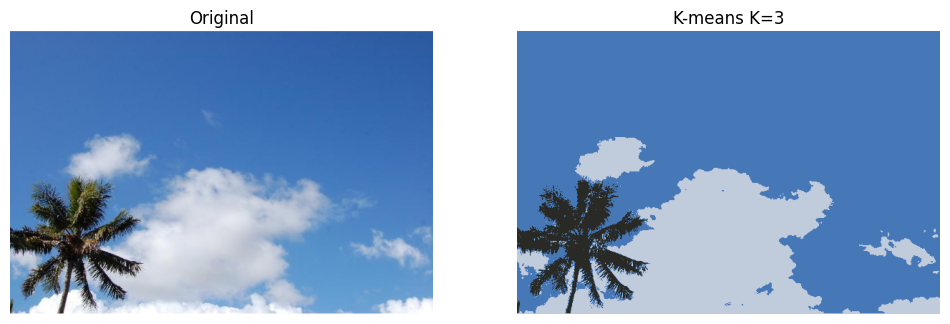

In [61]:
plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(img)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title(f"K-means K={K}")
plt.imshow(result)
plt.axis("off")

plt.show()